ARTI406 - Machine Learning

# Assignment 1: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

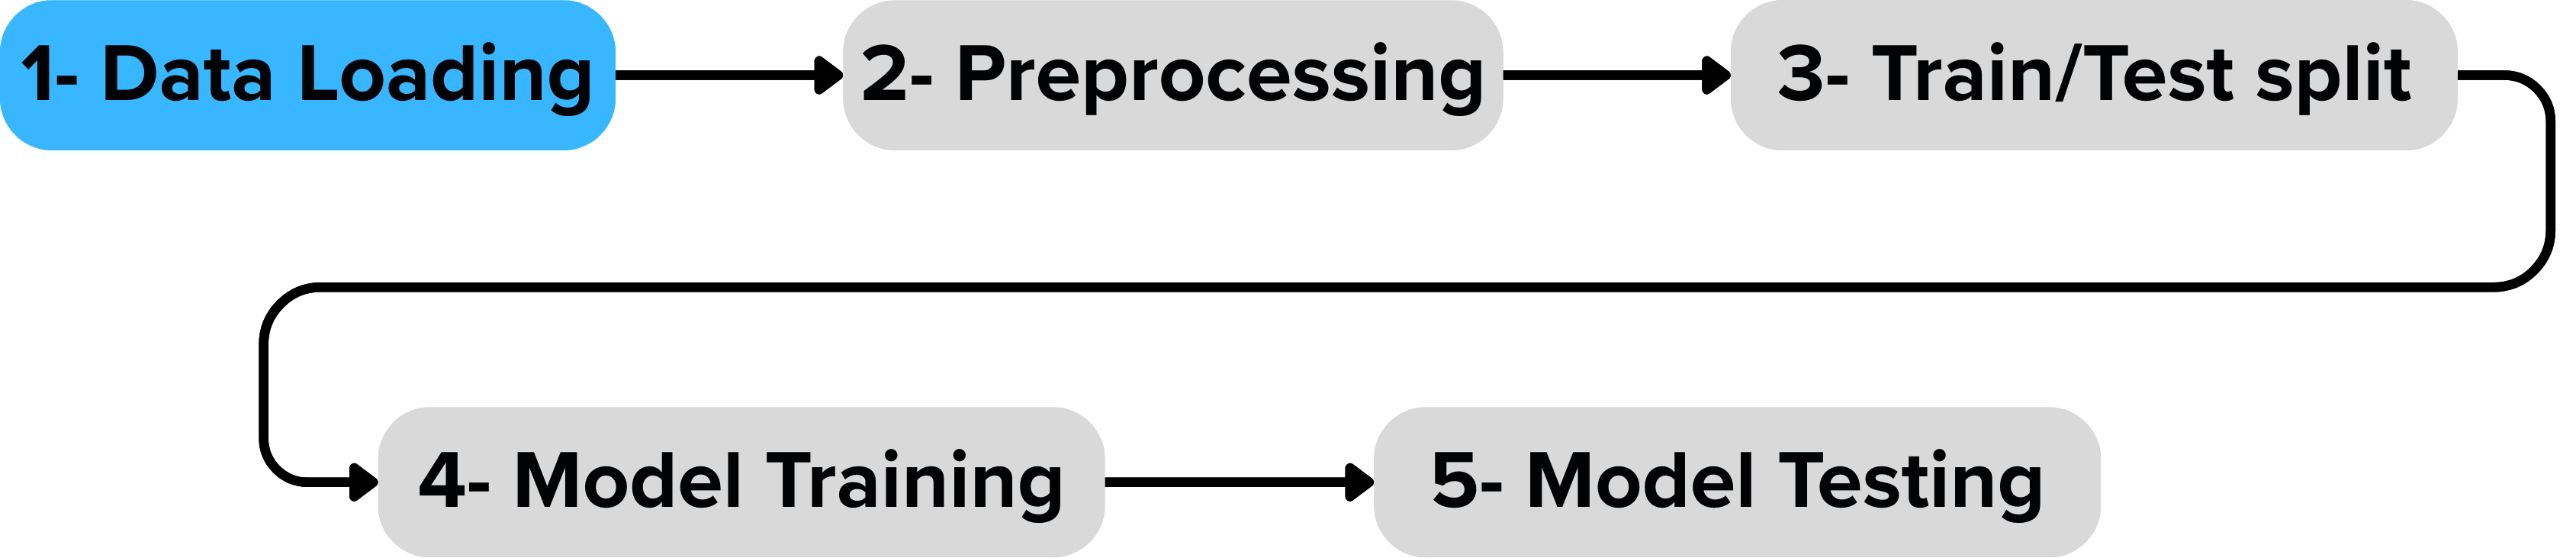

In [23]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

### Dataset Description

- The dataset includes YouTube trending data from multiple countries. Each country has a separate dataset file. In my assignment, i only used the United States dataset (USvideos.csv) to perform the analysis and extract insights.

In [71]:
# Load Dataset
df = pd.read_csv("USvideos.csv")
# Display first 5 rows. If you want to display all rows, use df.head(-1)
df.head(-1)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40943,1PhPYr_9zRY,18.14.06,BTS Plays With Puppies While Answering Fan Que...,BuzzFeed Celeb,22,2018-05-18T16:39:29.000Z,"BuzzFeed|""BuzzFeedVideo""|""Puppy Interview""|""pu...",8259128,645888,4052,62610,https://i.ytimg.com/vi/1PhPYr_9zRY/default.jpg,False,False,False,"BTS with the PPS, the puppies. These adorable ..."
40944,BZt0qjTWNhw,18.14.06,The Cat Who Caught the Laser,AaronsAnimals,15,2018-05-18T13:00:04.000Z,"aarons animals|""aarons""|""animals""|""cat""|""cats""...",1685609,38160,1385,2657,https://i.ytimg.com/vi/BZt0qjTWNhw/default.jpg,False,False,False,The Cat Who Caught the Laser - Aaron's Animals
40945,1h7KV2sjUWY,18.14.06,True Facts : Ant Mutualism,zefrank1,22,2018-05-18T01:00:06.000Z,[none],1064798,60008,382,3936,https://i.ytimg.com/vi/1h7KV2sjUWY/default.jpg,False,False,False,NaN
40946,D6Oy4LfoqsU,18.14.06,I GAVE SAFIYA NYGAARD A PERFECT HAIR MAKEOVER ...,Brad Mondo,24,2018-05-18T17:34:22.000Z,I gave safiya nygaard a perfect hair makeover ...,1066451,48068,1032,3992,https://i.ytimg.com/vi/D6Oy4LfoqsU/default.jpg,False,False,False,I had so much fun transforming Safiyas hair in...


### Check Missing Values

In [62]:
# Check all values
print(df.isna())

       video_id  trending_date  title  channel_title  category_id  \
0         False          False  False          False        False   
1         False          False  False          False        False   
2         False          False  False          False        False   
3         False          False  False          False        False   
4         False          False  False          False        False   
...         ...            ...    ...            ...          ...   
40944     False          False  False          False        False   
40945     False          False  False          False        False   
40946     False          False  False          False        False   
40947     False          False  False          False        False   
40948     False          False  False          False        False   

       publish_time   tags  views  likes  dislikes  comment_count  \
0             False  False  False  False     False          False   
1             False  False  False

In [57]:
print(df.isna().sum())

video_id                    0
trending_date               0
title                       0
channel_title               0
category_id                 0
publish_time                0
tags                        0
views                       0
likes                       0
dislikes                    0
comment_count               0
thumbnail_link              0
comments_disabled           0
ratings_disabled            0
video_error_or_removed      0
description               570
category_name               0
month                       0
dtype: int64


### Check duplicate rows

In [58]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

34899    True
34900    True
34901    True
34902    True
34903    True
34904    True
34905    True
34906    True
34907    True
34908    True
34909    True
34910    True
34911    True
34913    True
34914    True
34915    True
34916    True
34917    True
34918    True
34919    True
34921    True
34922    True
34923    True
34924    True
34925    True
34926    True
34927    True
34928    True
34929    True
34930    True
34931    True
34932    True
34933    True
34934    True
34935    True
34936    True
34937    True
34938    True
34939    True
34940    True
34941    True
34942    True
34943    True
34944    True
34945    True
34946    True
34947    True
34948    True
dtype: bool

### No. of rows and columns

In [61]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (40949, 18) 

number of rows:  40949
number of columns:  18


### Data type of columns

In [72]:
# viewing the data types of columns
df.dtypes

video_id                    str
trending_date               str
title                       str
channel_title               str
category_id               int64
publish_time                str
tags                        str
views                     int64
likes                     int64
dislikes                  int64
comment_count             int64
thumbnail_link              str
comments_disabled          bool
ratings_disabled           bool
video_error_or_removed     bool
description                 str
dtype: object

In [73]:
df['publish_time'] = pd.to_datetime(df['publish_time'], errors='coerce')
df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m', errors='coerce')

df.dtypes

video_id                                  str
trending_date                  datetime64[us]
title                                     str
channel_title                             str
category_id                             int64
publish_time              datetime64[us, UTC]
tags                                      str
views                                   int64
likes                                   int64
dislikes                                int64
comment_count                           int64
thumbnail_link                            str
comments_disabled                        bool
ratings_disabled                         bool
video_error_or_removed                   bool
description                               str
dtype: object

In [31]:
# Statistical summary
df.describe(include='all')

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
count,40949,40949,40949,40949,40949.000000,40949,40949,4.094900e+04,4.094900e+04,4.094900e+04,4.094900e+04,40949,40949,40949,40949,40379
unique,6351,NaN,6455,2207,NaN,NaN,6055,NaN,NaN,NaN,NaN,6352,2,2,2,6901
top,j4KvrAUjn6c,NaN,WE MADE OUR MOM CRY...HER DREAM CAME TRUE!,ESPN,NaN,NaN,[none],NaN,NaN,NaN,NaN,https://i.ytimg.com/vi/j4KvrAUjn6c/default.jpg,False,False,False,► Listen LIVE: http://power1051fm.com/\n► Face...
freq,30,NaN,30,203,NaN,NaN,1535,NaN,NaN,NaN,NaN,30,40316,40780,40926,58
mean,NaN,2018-02-27 06:22:42.494810,NaN,NaN,19.972429,2018-02-11 01:00:49.258590+00:00,NaN,2.360785e+06,7.426670e+04,3.711401e+03,8.446804e+03,NaN,NaN,NaN,NaN,NaN
min,NaN,2017-11-14 00:00:00,NaN,NaN,1.000000,2006-07-23 08:24:11+00:00,NaN,5.490000e+02,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN,NaN
25%,NaN,2018-01-04 00:00:00,NaN,NaN,17.000000,2017-12-27 21:00:00+00:00,NaN,2.423290e+05,5.424000e+03,2.020000e+02,6.140000e+02,NaN,NaN,NaN,NaN,NaN
50%,NaN,2018-02-26 00:00:00,NaN,NaN,24.000000,2018-02-21 16:19:27+00:00,NaN,6.818610e+05,1.809100e+04,6.310000e+02,1.856000e+03,NaN,NaN,NaN,NaN,NaN
75%,NaN,2018-04-24 00:00:00,NaN,NaN,25.000000,2018-04-16 17:20:26+00:00,NaN,1.823157e+06,5.541700e+04,1.938000e+03,5.755000e+03,NaN,NaN,NaN,NaN,NaN
max,NaN,2018-06-14 00:00:00,NaN,NaN,43.000000,2018-06-14 01:31:53+00:00,NaN,2.252119e+08,5.613827e+06,1.674420e+06,1.361580e+06,NaN,NaN,NaN,NaN,NaN


### Converting Category IDs to Category Names

In [47]:
import json

with open('US_category_id.json') as f:
    category_data = json.load(f)

In [51]:
category_dict = {}

for item in category_data['items']:
    category_dict[int(item['id'])] = item['snippet']['title']
df['category_name'] = df['category_id'].map(category_dict)
df[['category_id', 'category_name']].head()

,category_id,category_name
0,22,People & Blogs
1,24,Entertainment
2,23,Comedy
3,24,Entertainment
4,24,Entertainment


### Descriptive summary Statistics

### Univariate Analysis

### Distribution of Views

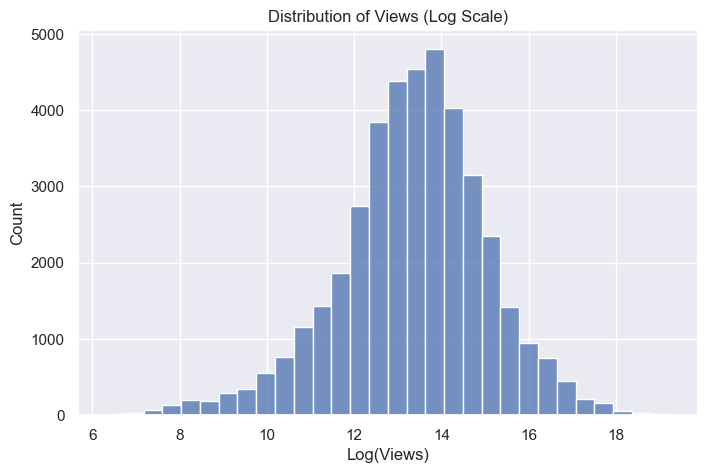

In [32]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df['views']), bins=30)
plt.title("Distribution of Views (Log Scale)")
plt.xlabel("Log(Views)")
plt.show()

- Shows how video views are distributed  
- Right skew = most videos have low views, while a few videos have extremely high views  

### Distribution of Comments

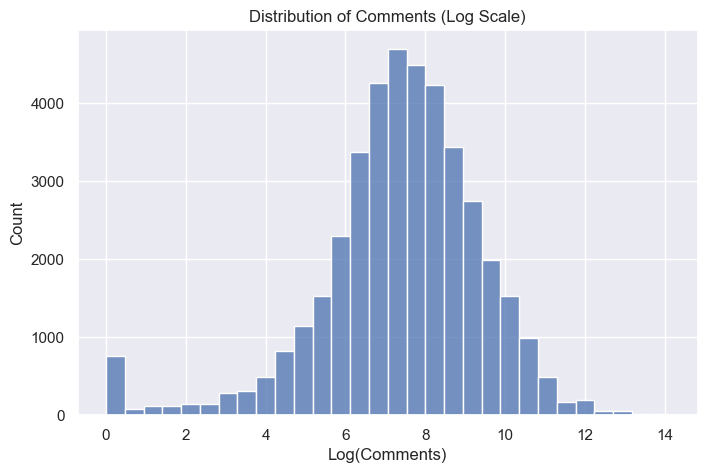

In [39]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df['comment_count']), bins=30)
plt.title("Distribution of Comments (Log Scale)")
plt.xlabel("Log(Comments)")
plt.show()

- Shows the distribution of comments on videos  
- Right skew = most videos have few comments, while a few videos receive very high engagement 
- Videos with many comments usually have higher audience interaction   

### Distribution of Likes

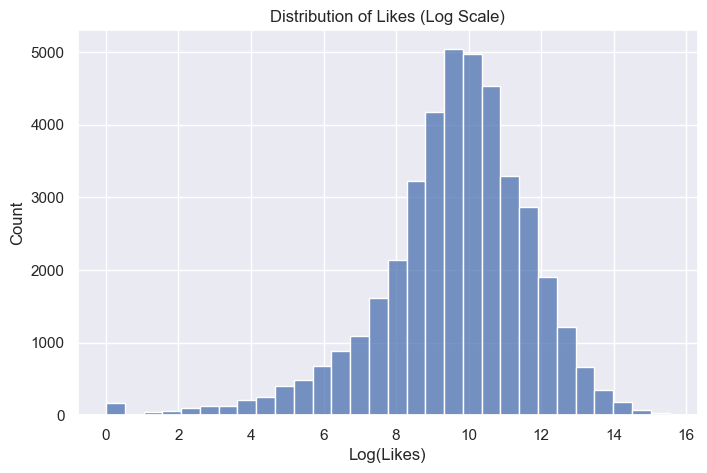

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df['likes']), bins=30)
plt.title("Distribution of Likes (Log Scale)")
plt.xlabel("Log(Likes)")
plt.show()

- Shows how likes are distributed across videos  
- Right skew = most videos receive few likes, while a small number get very high likes  
- High likes often indicate popular or trending content 

## Bivariate Analysis
### Relationship Between Views and Likes

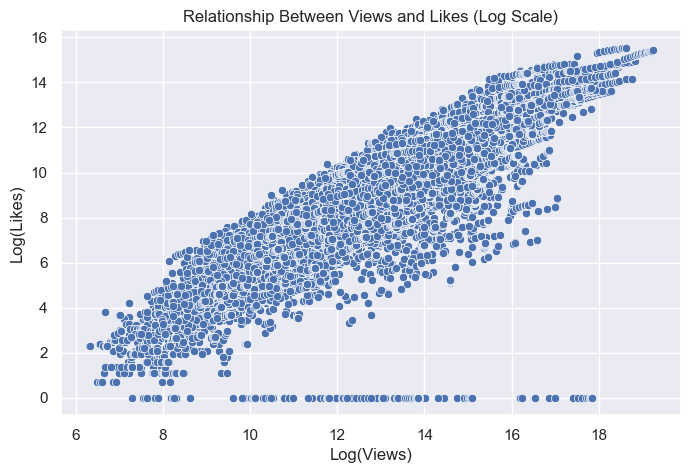

In [42]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=np.log1p(df['views']), y=np.log1p(df['likes']))
plt.title("Relationship Between Views and Likes (Log Scale)")
plt.xlabel("Log(Views)")
plt.ylabel("Log(Likes)")
plt.show()

### Relationship Between Likes and Comments

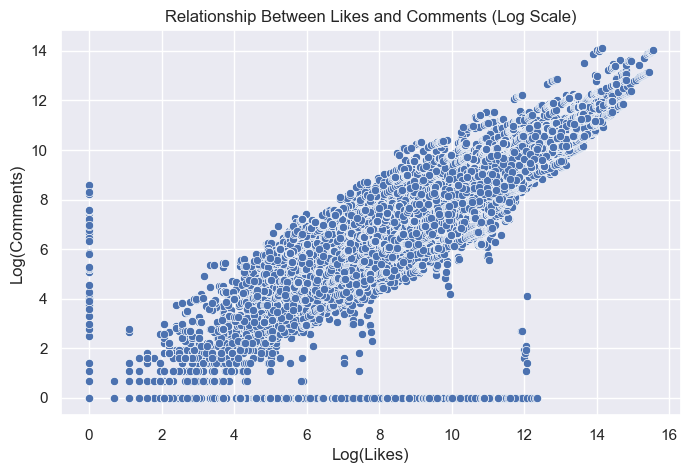

In [44]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=np.log1p(df['likes']), y=np.log1p(df['comment_count']))
plt.title("Relationship Between Likes and Comments (Log Scale)")
plt.xlabel("Log(Likes)")
plt.ylabel("Log(Comments)")
plt.show()

### Average Views by Category

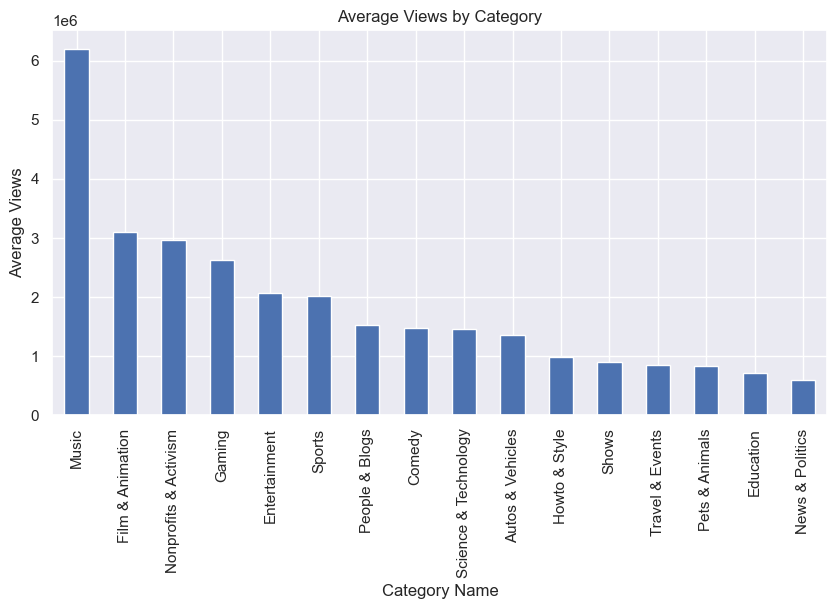

In [52]:
category_views = df.groupby('category_name')['views'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
category_views.plot(kind='bar')
plt.title("Average Views by Category")
plt.xlabel("Category Name")
plt.ylabel("Average Views")
plt.show()

- Shows the average views across different categories  
- Some categories receive higher views than others  
- This suggests differences in audience interest between categories  

### Relationship Between Views and Comment Count

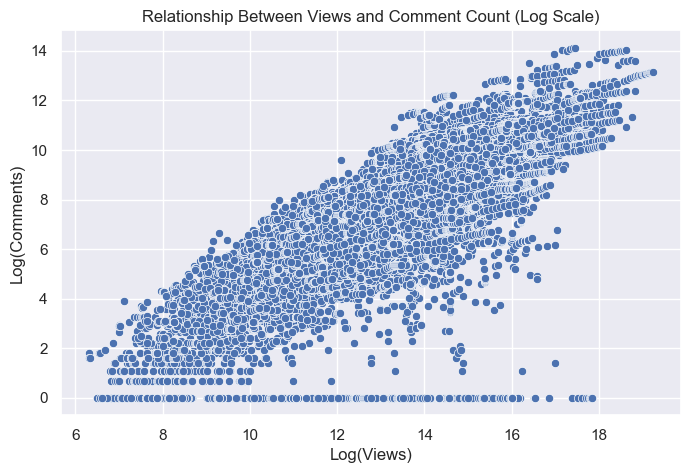

In [43]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=np.log1p(df['views']), y=np.log1p(df['comment_count']))
plt.title("Relationship Between Views and Comment Count (Log Scale)")
plt.xlabel("Log(Views)")
plt.ylabel("Log(Comments)")
plt.show()

### Top Channels

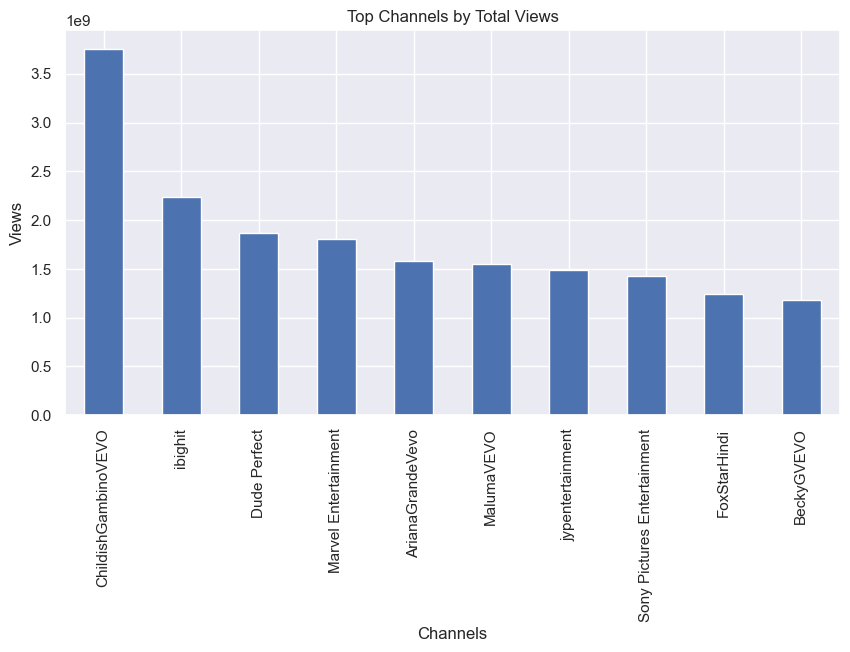

In [74]:
top_channels = df.groupby('channel_title')['views'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_channels.plot(kind='bar')
plt.title("Top Channels by Total Views")
plt.xlabel("Channels")
plt.ylabel("Views")
plt.show()

- Shows how total views change over time  
- Some months have higher views than others  
- This indicates fluctuations in video popularity over time  
- Peaks may represent viral trends or increased user activity  

### Correlation Matrix

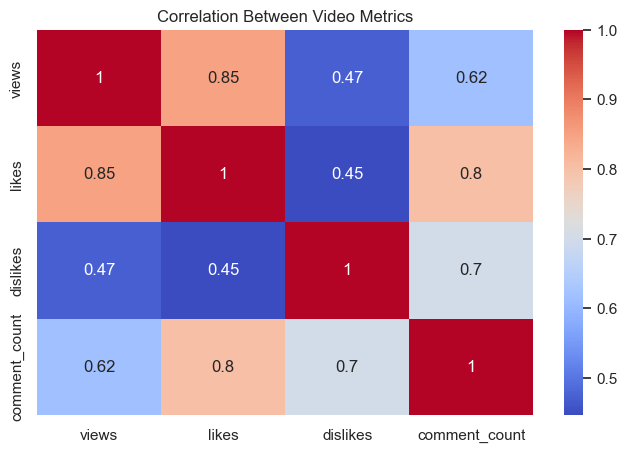

In [53]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['views','likes','dislikes','comment_count']].corr(), 
            annot=True, cmap='coolwarm')

plt.title("Correlation Between Video Metrics")
plt.show()

- Shows the correlation between views, likes, dislikes, and comments  
- Values close to 1 indicate a strong positive relationship  
- Values close to 0 indicate a weak or no relationship  
- Views and likes have a strong positive correlation  
- Higher views generally lead to higher engagement (likes and comments)  

## Time-Based Analysis
### Monthly Views Trend

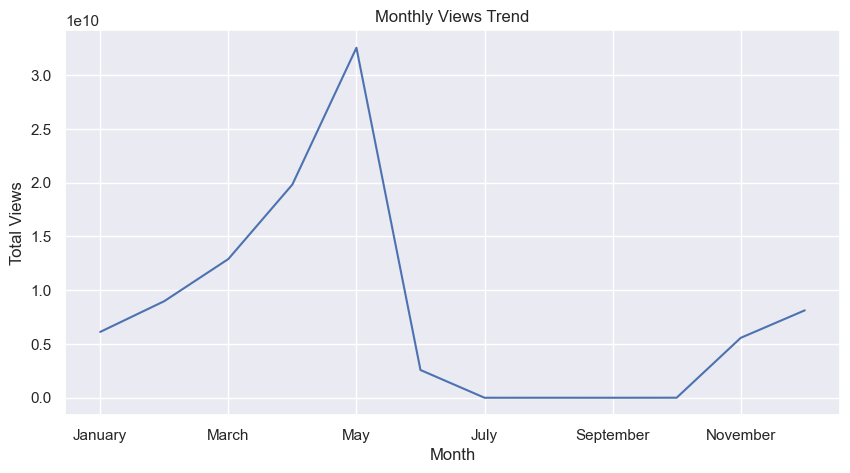

In [55]:
df['month'] = df['publish_time'].dt.month_name()

monthly_views = df.groupby('month')['views'].sum()

monthly_views = monthly_views.reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

plt.figure(figsize=(10,5))
monthly_views.plot()
plt.title("Monthly Views Trend")
plt.xlabel("Month")
plt.ylabel("Total Views")
plt.show()

# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the following to the assignment 1 folder.
1. Dataset file 
2. Dataset Description readme file
2. Jupyter Notebook


- Name : Noor Mustafa Al-Hahsim
- ID : 2230000582